In [126]:
# Import libraries
import pandas as pd
import numpy as np

### Load data

In [127]:
# Read in the dataset
Load_History = pd.read_csv(r"C:\Users\ANNA MANI\Downloads\AI_Assignment\Load_History .csv")

# List out our columns
Load_History.head()

,Unnamed: 0,POWER_MW,Temp_FC,Rain_FC,is_holiday
0,1/1/2022 0:00,1420.568008,24.715466,0.107205,1
1,1/1/2022 1:00,1370.015054,24.479847,0.087264,1
2,1/1/2022 2:00,1332.844189,24.229276,0.021265,1
3,1/1/2022 3:00,1300.437874,23.967832,0.023627,1
4,1/1/2022 4:00,1290.500864,24.299130,0.014556,1


### Data description

In [128]:
Load_History.describe()

,POWER_MW,Temp_FC,Rain_FC,is_holiday
count,17158.000000,18101.000000,18104.000000,18120.000000
mean,1611.294723,26.417082,0.486610,0.083444
std,224.220993,2.373485,0.934296,0.276559
min,980.271083,20.142269,0.000000,0.000000
25%,1453.165813,24.689717,0.009598,0.000000
50%,1596.547341,26.053240,0.089319,0.000000
75%,1757.637917,27.778399,0.508387,0.000000
max,2496.676625,34.799697,10.296448,1.000000


### Data visualization

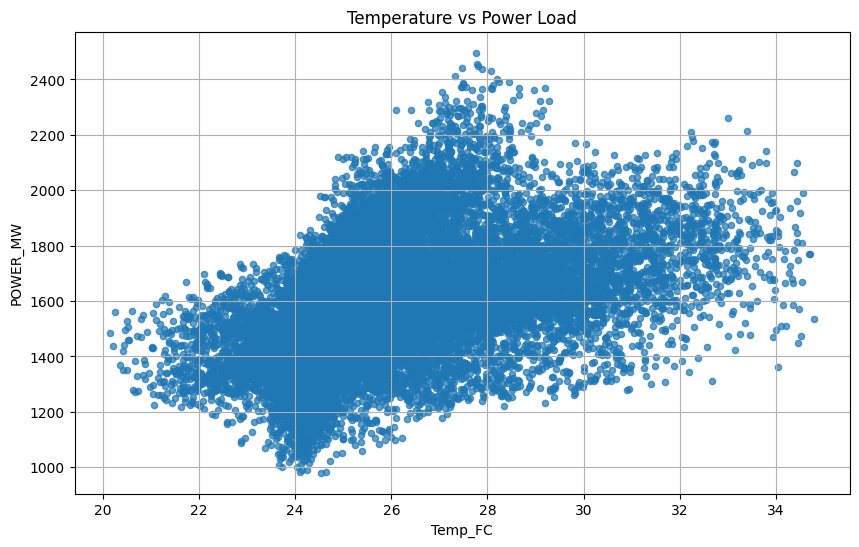

In [129]:
# Scatter plot using pandas
ax1= Load_History.plot(kind='scatter', x='Temp_FC', y='POWER_MW', alpha=0.7, figsize=(10, 6), title="Temperature vs Power Load")
ax1.grid(True)

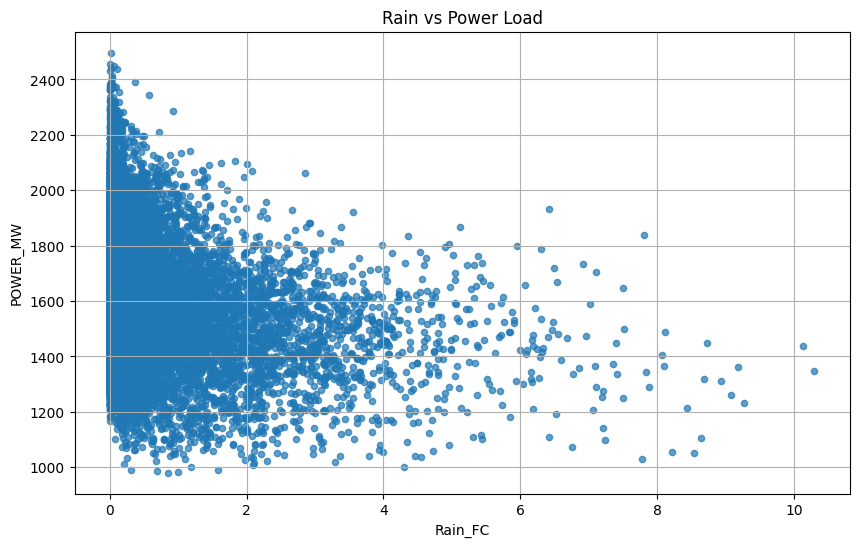

In [130]:
# Scatter plot using pandas
ax1= Load_History.plot(kind='scatter', x='Rain_FC', y='POWER_MW', alpha=0.7, figsize=(10, 6), title="Rain vs Power Load")
ax1.grid(True)

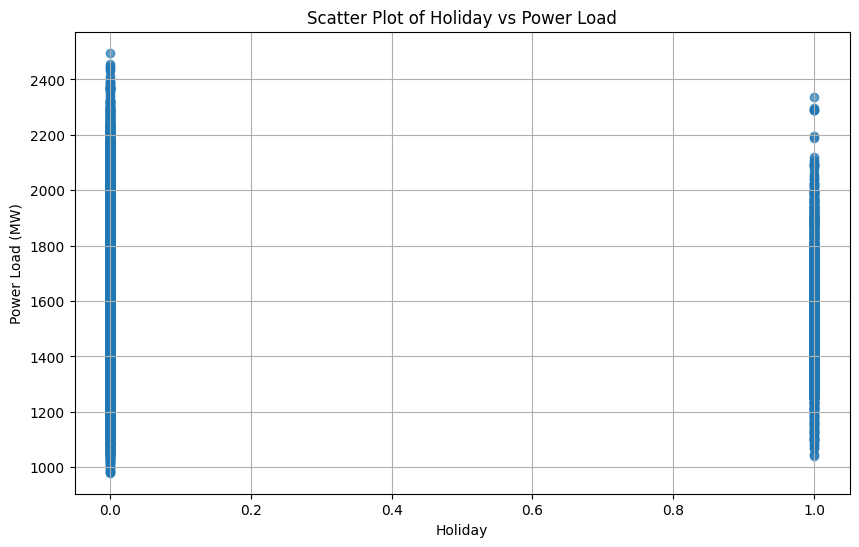

In [131]:
import matplotlib.pyplot as plt

# Scatter plot for two variables: Temp_FC vs POWER_MW
plt.figure(figsize=(10, 6))
plt.scatter(Load_History['is_holiday'], Load_History['POWER_MW'], alpha=0.7)
plt.title("Scatter Plot of Holiday vs Power Load")
plt.xlabel("Holiday")
plt.ylabel("Power Load (MW)")
plt.grid(True)
plt.show()

### Outlier detection (Done using box plots)

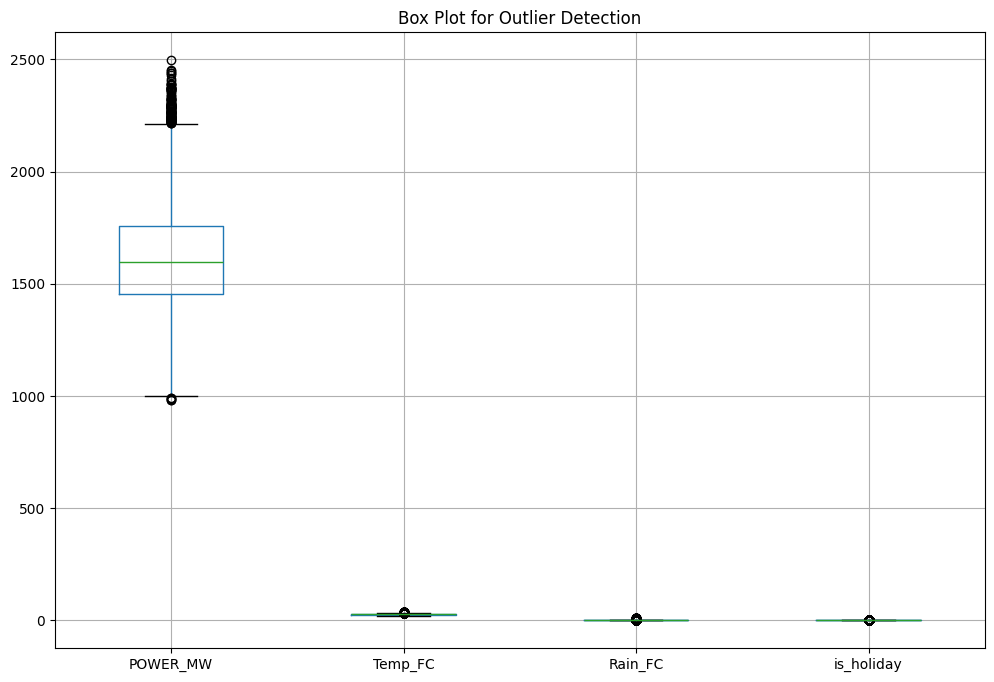

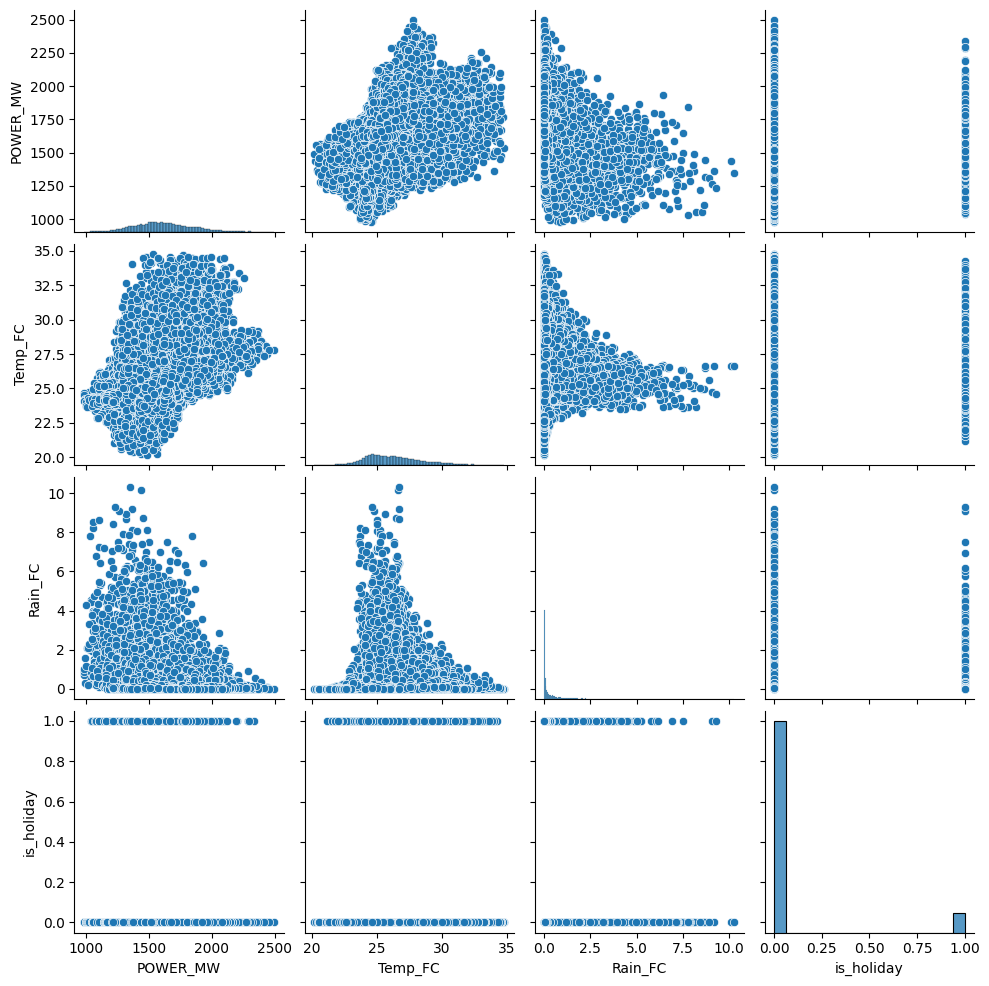

In [132]:
# Box plot for each variable
Load_History.boxplot(figsize=(12, 8))
plt.title("Box Plot for Outlier Detection")
plt.show()

# Scatter plot for relationships (pairwise plots)
import seaborn as sns
sns.pairplot(Load_History)
plt.show()


### Missing values count

In [133]:
missing_values = Load_History.isnull().sum()
missing_values

Unnamed: 0      0
POWER_MW      962
Temp_FC        19
Rain_FC        16
is_holiday      0
dtype: int64

### Selecting data from 01-01-2022 00:00 till 24-12-2023 23:00

In [134]:
import pandas as pd

# Ensure the 'Unnamed: 0' column is in datetime format
Load_History['Unnamed: 0'] = pd.to_datetime(Load_History['Unnamed: 0'])

# Define the end time
end_time = pd.Timestamp("2023-12-24 23:00:00")

# Filter the data from the start to the defined end time
filtered_data = Load_History[
    Load_History['Unnamed: 0'] <= end_time
]

# Print a preview of the filtered data
print(filtered_data.head())

           Unnamed: 0     POWER_MW    Temp_FC   Rain_FC  is_holiday
0 2022-01-01 00:00:00  1420.568008  24.715466  0.107205           1
1 2022-01-01 01:00:00  1370.015054  24.479847  0.087264           1
2 2022-01-01 02:00:00  1332.844189  24.229276  0.021265           1
3 2022-01-01 03:00:00  1300.437874  23.967832  0.023627           1
4 2022-01-01 04:00:00  1290.500864  24.299130  0.014556           1


### Finding missing data Points

In [135]:
# Calculate the count of missing values for each column
missing_count = filtered_data.isnull().sum()

# Calculate the percentage of missing values for each column
missing_percentage = (missing_count / len(filtered_data)) * 100

# Combine both into a single DataFrame for better readability
missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage': missing_percentage
}).sort_values(by='Missing Count', ascending=False)

# Print the summary
print(missing_summary)

            Missing Count  Missing Percentage
POWER_MW              194            1.118027
Temp_FC                19            0.109497
Rain_FC                16            0.092208
Unnamed: 0              0            0.000000
is_holiday              0            0.000000


In [136]:
# Fill missing values in the filtered_data DataFrame with the mean of each column
filtered_data_filled = filtered_data.fillna(filtered_data.mean())

# Print a preview of the data after filling missing values
print(filtered_data_filled.head())

           Unnamed: 0     POWER_MW    Temp_FC   Rain_FC  is_holiday
0 2022-01-01 00:00:00  1420.568008  24.715466  0.107205           1
1 2022-01-01 01:00:00  1370.015054  24.479847  0.087264           1
2 2022-01-01 02:00:00  1332.844189  24.229276  0.021265           1
3 2022-01-01 03:00:00  1300.437874  23.967832  0.023627           1
4 2022-01-01 04:00:00  1290.500864  24.299130  0.014556           1


In [137]:
filtered_data.describe()

,Unnamed: 0,POWER_MW,Temp_FC,Rain_FC,is_holiday
count,17352,17158.000000,17333.000000,17336.000000,17352.000000
mean,2022-12-28 11:30:00,1611.294723,26.404553,0.503787,0.082988
min,2022-01-01 00:00:00,980.271083,20.142269,0.000000,0.000000
25%,2022-06-30 17:45:00,1453.165813,24.693247,0.011041,0.000000
50%,2022-12-28 11:30:00,1596.547341,26.049512,0.099364,0.000000
75%,2023-06-27 05:15:00,1757.637917,27.742687,0.540687,0.000000
max,2023-12-24 23:00:00,2496.676625,34.799697,10.296448,1.000000
std,NaN,224.220993,2.367405,0.949012,0.275871


In [138]:
# DataFrame with rows containing any missing values dropped
df_dropped_rows = filtered_data.dropna()

# DataFrame with missing values filled with the mean of each column
df_filled_mean = filtered_data.fillna(filtered_data.mean())

# Display the summaries of both DataFrames for verification
print("DataFrame after dropping rows with missing values:")
print(df_dropped_rows)

print("\nDataFrame after filling missing values with column means:")
print(df_filled_mean)


DataFrame after dropping rows with missing values:
               Unnamed: 0     POWER_MW    Temp_FC   Rain_FC  is_holiday
0     2022-01-01 00:00:00  1420.568008  24.715466  0.107205           1
1     2022-01-01 01:00:00  1370.015054  24.479847  0.087264           1
2     2022-01-01 02:00:00  1332.844189  24.229276  0.021265           1
3     2022-01-01 03:00:00  1300.437874  23.967832  0.023627           1
4     2022-01-01 04:00:00  1290.500864  24.299130  0.014556           1
...                   ...          ...        ...       ...         ...
17347 2023-12-24 19:00:00  1832.216375  27.000419  0.007925           1
17348 2023-12-24 20:00:00  1809.411250  26.433602  0.000000           1
17349 2023-12-24 21:00:00  1810.305375  26.001906  0.000000           1
17350 2023-12-24 22:00:00  1784.333375  25.646462  0.000000           1
17351 2023-12-24 23:00:00  1662.568500  25.321409  0.000000           1

[17129 rows x 5 columns]

DataFrame after filling missing values with column means:


### Dataframe after dropping rows with missing values

In [139]:
df_dropped_rows.describe()

,Unnamed: 0,POWER_MW,Temp_FC,Rain_FC,is_holiday
count,17129,17129.000000,17129.000000,17129.000000,17129.000000
mean,2022-12-27 01:14:52.801681408,1611.142808,26.388038,0.508791,0.079806
min,2022-01-01 00:00:00,980.271083,20.142269,0.000000,0.000000
25%,2022-06-29 11:00:00,1452.817500,24.684350,0.011620,0.000000
50%,2022-12-24 21:00:00,1596.462375,26.034043,0.101997,0.000000
75%,2023-06-27 12:00:00,1757.503250,27.729280,0.547278,0.000000
max,2023-12-24 23:00:00,2496.676625,34.799697,10.296448,1.000000
std,NaN,224.272834,2.355080,0.953296,0.271001


### Dataframe after filling in missing values with the mean

In [140]:
df_filled_mean.describe()

,Unnamed: 0,POWER_MW,Temp_FC,Rain_FC,is_holiday
count,17352,17352.000000,17352.000000,17352.000000,17352.000000
mean,2022-12-28 11:30:00,1611.294723,26.404553,0.503787,0.082988
min,2022-01-01 00:00:00,980.271083,20.142269,0.000000,0.000000
25%,2022-06-30 17:45:00,1455.032781,24.694538,0.011061,0.000000
50%,2022-12-28 11:30:00,1599.443149,26.052058,0.099638,0.000000
75%,2023-06-27 05:15:00,1755.572313,27.740118,0.540208,0.000000
max,2023-12-24 23:00:00,2496.676625,34.799697,10.296448,1.000000
std,NaN,222.963972,2.366109,0.948574,0.275871


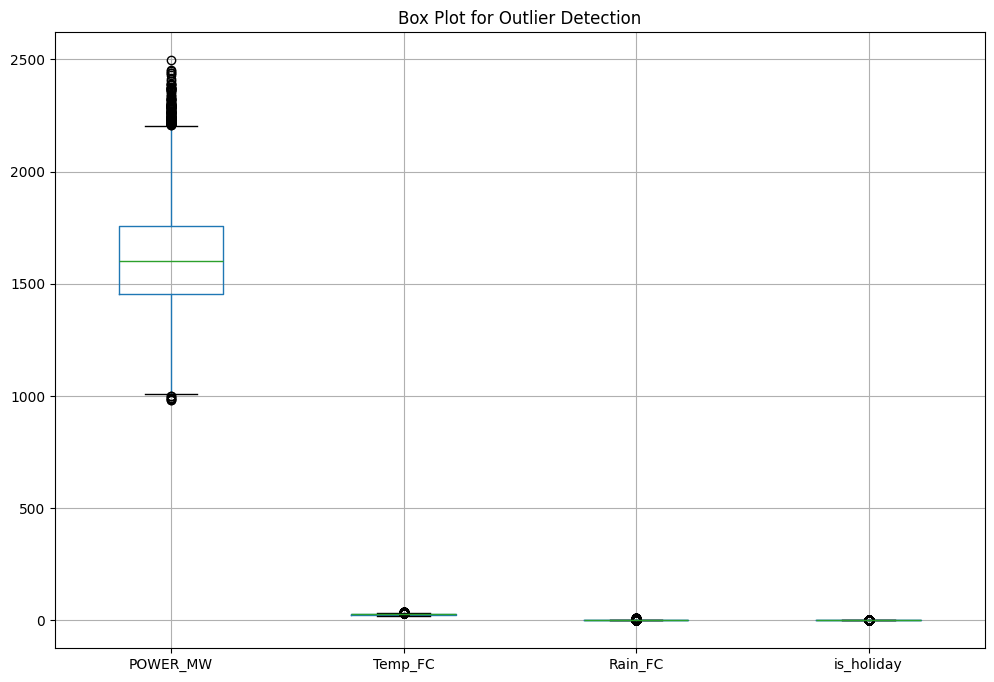

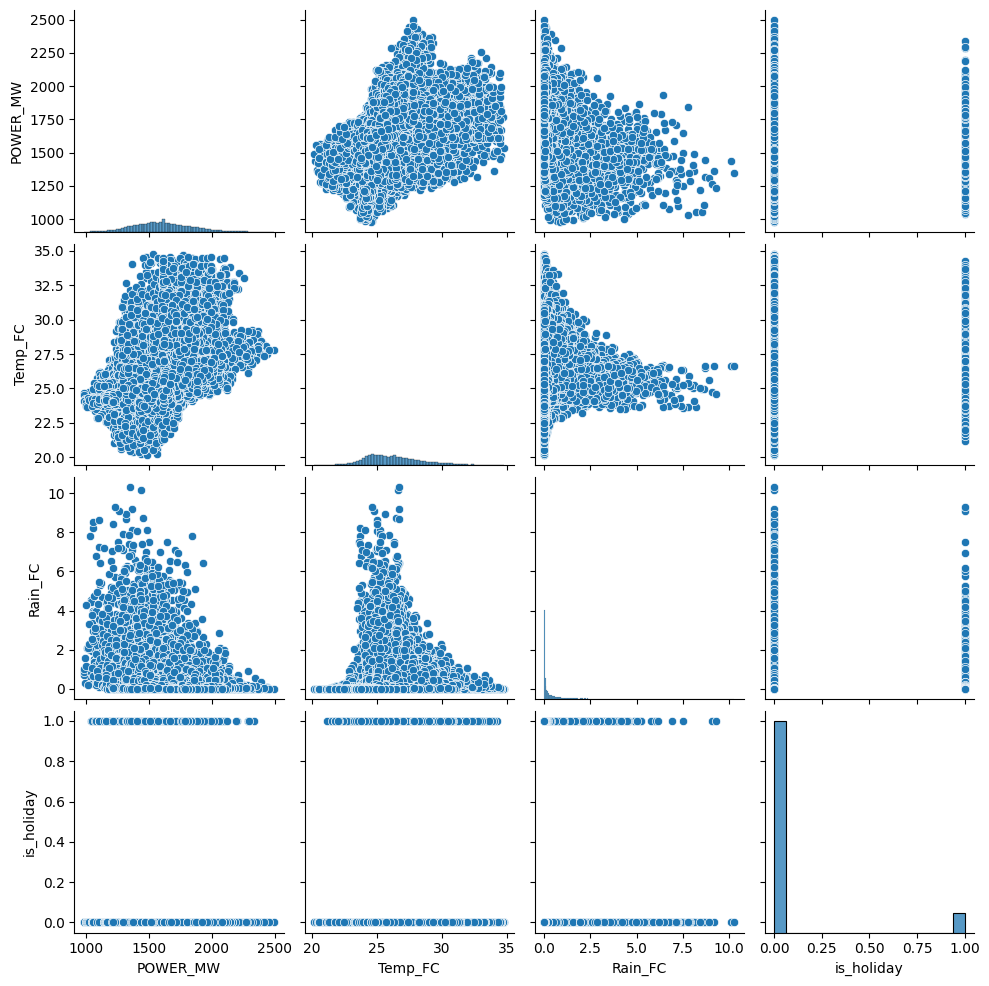

In [141]:
# Box plot for each variable
df_filled_mean.boxplot(figsize=(12, 8))
plt.title("Box Plot for Outlier Detection")
plt.show()

# Scatter plot for relationships (pairwise plots)
import seaborn as sns
sns.pairplot(df_filled_mean)
plt.show()


### Data Scaling using MinMax Scaler

In [142]:
from sklearn.preprocessing import MinMaxScaler

# Create a MinMaxScaler object
scaler = MinMaxScaler()

# Select columns to scale (exclude non-numeric columns or the target variable)
columns_to_scale = ['Temp_FC', 'Rain_FC', 'is_holiday']  
df_scaled = df_filled_mean.copy()

# Apply Min-Max Scaling
df_scaled[columns_to_scale] = scaler.fit_transform(df_filled_mean[columns_to_scale])

# Display scaled data
print(df_scaled.head())


           Unnamed: 0     POWER_MW   Temp_FC   Rain_FC  is_holiday
0 2022-01-01 00:00:00  1420.568008  0.312005  0.010412         1.0
1 2022-01-01 01:00:00  1370.015054  0.295930  0.008475         1.0
2 2022-01-01 02:00:00  1332.844189  0.278835  0.002065         1.0
3 2022-01-01 03:00:00  1300.437874  0.260998  0.002295         1.0
4 2022-01-01 04:00:00  1290.500864  0.283601  0.001414         1.0


### Segregation of data seasonally

In [143]:
# Function to map months to seasons
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'
        
df_scaled['Season'] = df_scaled['Unnamed: 0'].dt.month.apply(get_season)

# Create the Season column
df_scaled['Season'] = df_scaled['Unnamed: 0'].dt.month.apply(get_season)

# Filter data for each season into separate DataFrames
winter_data = df_scaled[df_scaled['Season'] == 'Winter']
spring_data = df_scaled[df_scaled['Season'] == 'Spring']
summer_data = df_scaled[df_scaled['Season'] == 'Summer']
autumn_data = df_scaled[df_scaled['Season'] == 'Autumn']

# Verify the sizes of the seasonal DataFrames
print(f"Winter Data: {winter_data.shape}")
print(f"Spring Data: {spring_data.shape}")
print(f"Summer Data: {summer_data.shape}")
print(f"Autumn Data: {autumn_data.shape}")

Winter Data: (4152, 6)
Spring Data: (4416, 6)
Summer Data: (4416, 6)
Autumn Data: (4368, 6)


In [144]:
df_filled_mean.describe()

,Unnamed: 0,POWER_MW,Temp_FC,Rain_FC,is_holiday
count,17352,17352.000000,17352.000000,17352.000000,17352.000000
mean,2022-12-28 11:30:00,1611.294723,26.404553,0.503787,0.082988
min,2022-01-01 00:00:00,980.271083,20.142269,0.000000,0.000000
25%,2022-06-30 17:45:00,1455.032781,24.694538,0.011061,0.000000
50%,2022-12-28 11:30:00,1599.443149,26.052058,0.099638,0.000000
75%,2023-06-27 05:15:00,1755.572313,27.740118,0.540208,0.000000
max,2023-12-24 23:00:00,2496.676625,34.799697,10.296448,1.000000
std,NaN,222.963972,2.366109,0.948574,0.275871


### Segregation of Data based on day and night

In [145]:
# Function to classify hours into day or night
def get_day_night(hour):
    if 6 <= hour < 18:
        return 'Day'
    else:
        return 'Night'

# Add 'Day_Night' column
df_scaled['Day_Night'] = df_scaled['Unnamed: 0'].dt.hour.apply(get_day_night)

# Filter data for Day and Night into separate DataFrames
day_data = df_scaled[df_scaled['Day_Night'] == 'Day']
night_data = df_scaled[df_scaled['Day_Night'] == 'Night']

# Verify the sizes of the new DataFrames
print(f"Day Data: {day_data.shape}")
print(f"Night Data: {night_data.shape}")

Day Data: (8676, 7)
Night Data: (8676, 7)


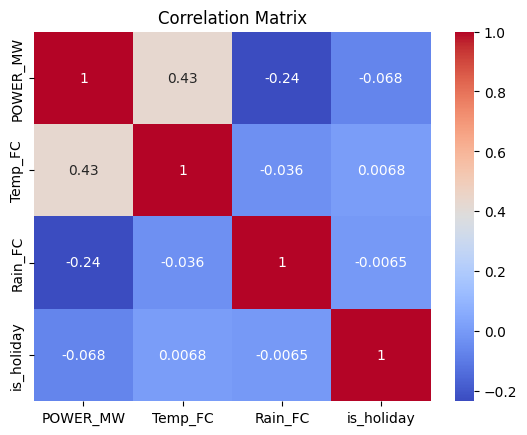

In [146]:
# Correlation heatmap
corr = df_filled_mean[['POWER_MW', 'Temp_FC', 'Rain_FC', 'is_holiday']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


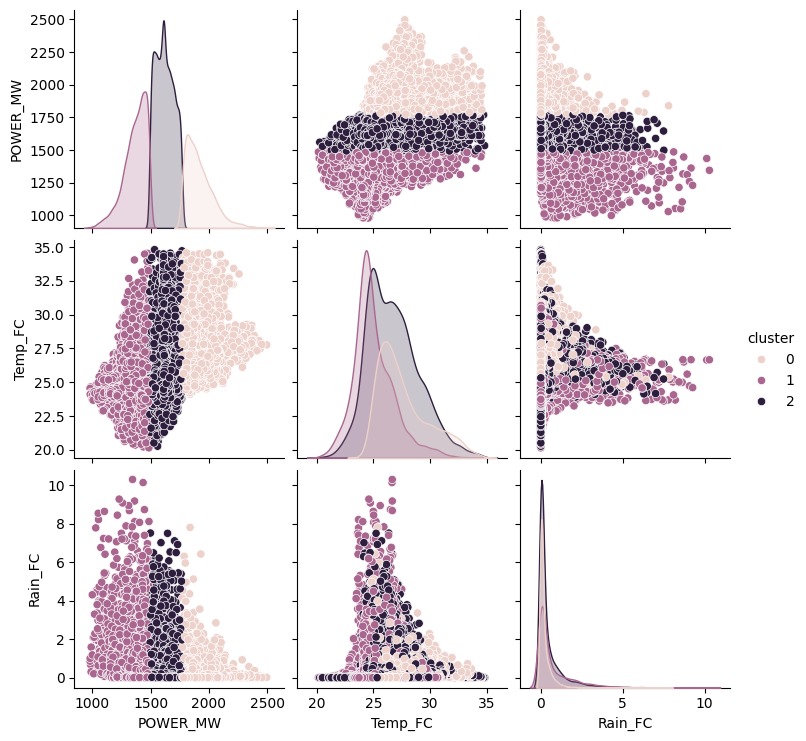

In [147]:
from sklearn.cluster import KMeans

# Select features for clustering
clustering_features = df_filled_mean[['POWER_MW', 'Temp_FC', 'Rain_FC']]
kmeans = KMeans(n_clusters=3, random_state=42)
df_filled_mean['cluster'] = kmeans.fit_predict(clustering_features)

# Visualize clusters
sns.pairplot(df_filled_mean, hue='cluster', vars=['POWER_MW', 'Temp_FC', 'Rain_FC'])
plt.show()


In [148]:
df_scaled

,Unnamed: 0,POWER_MW,Temp_FC,Rain_FC,is_holiday,Season,Day_Night
0,2022-01-01 00:00:00,1420.568008,0.312005,0.010412,1.0,Winter,Night
1,2022-01-01 01:00:00,1370.015054,0.295930,0.008475,1.0,Winter,Night
2,2022-01-01 02:00:00,1332.844189,0.278835,0.002065,1.0,Winter,Night
3,2022-01-01 03:00:00,1300.437874,0.260998,0.002295,1.0,Winter,Night
4,2022-01-01 04:00:00,1290.500864,0.283601,0.001414,1.0,Winter,Night
...,...,...,...,...,...,...,...
17347,2023-12-24 19:00:00,1832.216375,0.467896,0.000770,1.0,Winter,Night
17348,2023-12-24 20:00:00,1809.411250,0.429225,0.000000,1.0,Winter,Night
17349,2023-12-24 21:00:00,1810.305375,0.399773,0.000000,1.0,Winter,Night
17350,2023-12-24 22:00:00,1784.333375,0.375522,0.000000,1.0,Winter,Night


In [149]:
df_scaled.iloc[15000:,5]

15000    Autumn
15001    Autumn
15002    Autumn
15003    Autumn
15004    Autumn
          ...  
17347    Winter
17348    Winter
17349    Winter
17350    Winter
17351    Winter
Name: Season, Length: 2352, dtype: object

### Splitting the data for training and testing the model (whole data)

In [150]:
X = df_scaled.iloc[:,2:5]
y = df_scaled.iloc[:,1]

In [151]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes to verify
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (13881, 3)
X_test shape: (3471, 3)
y_train shape: (13881,)
y_test shape: (3471,)


### PLS Regression on whole data

In [152]:
from sklearn.cross_decomposition import PLSRegression

# Initialize the PLS regression model
# n_components: number of components to keep; start with a small value (e.g., 2) and tune based on results
pls_whole_data = PLSRegression(n_components=2)

# Fit the model to the training data
pls_whole_data.fit(X_train, y_train)



PLSRegression()

In [153]:
# Make predictions on the training and testing sets
y_train_pred = pls_whole_data.predict(X_train)
y_test_pred = pls_whole_data.predict(X_test)

In [154]:
from sklearn.metrics import mean_squared_error, r2_score

# Evaluate model performance
train_rmse = mean_squared_error(y_train, y_train_pred, squared=False)
test_rmse = mean_squared_error(y_test, y_test_pred, squared=False)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Training RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Training R2: {train_r2:.2f}")
print(f"Test R2: {test_r2:.2f}")

# Print important components
print("PLS components:")
print(pls_whole_data.x_weights_)


Training RMSE: 194.95
Test RMSE: 192.73
Training R2: 0.24
Test R2: 0.25
PLS components:
[[ 0.86353839  0.32796787]
 [-0.48497409  0.74829958]
 [-0.13820846 -0.57661497]]


C:\Users\ANNA MANI\anaconda3\envs\cuda_pytorch\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\ANNA MANI\anaconda3\envs\cuda_pytorch\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


### Random Forest Regression on whole data

In [155]:
# Import necessary libraries
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor
rf_model_whole_data = RandomForestRegressor(
    n_estimators=100,  # Number of trees in the forest
    max_depth=None,    # Maximum depth of each tree (None = expand until pure leaf)
    random_state=42    # For reproducibility
)

# Fit the model to the training data
rf_model_whole_data.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [156]:
# Make predictions
y_train_pred = rf_model_whole_data.predict(X_train)
y_test_pred = rf_model_whole_data.predict(X_test)

# Evaluate the model
train_rmse = mean_squared_error(y_train, y_train_pred, squared=False)
test_rmse = mean_squared_error(y_test, y_test_pred, squared=False)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Training RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Training R²: {train_r2:.2f}")
print(f"Test R²: {test_r2:.2f}")


Training RMSE: 69.54
Test RMSE: 185.40
Training R²: 0.90
Test R²: 0.30


C:\Users\ANNA MANI\anaconda3\envs\cuda_pytorch\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\ANNA MANI\anaconda3\envs\cuda_pytorch\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


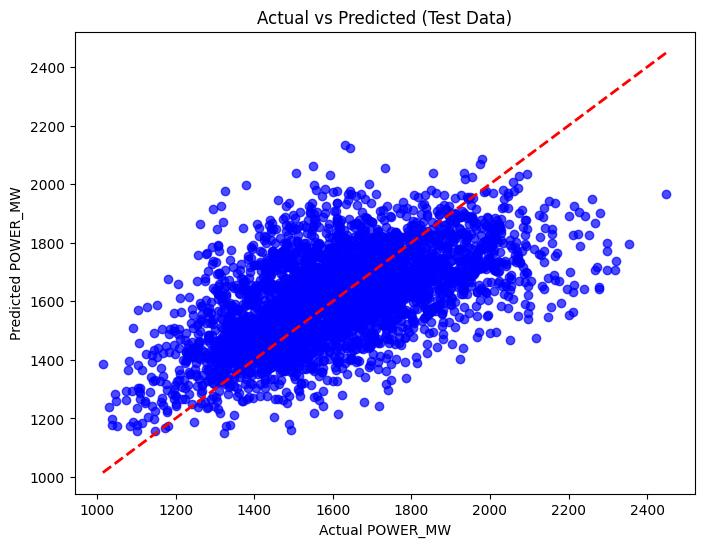

In [157]:
# Plot actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.7, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.title('Actual vs Predicted (Test Data)')
plt.xlabel('Actual POWER_MW')
plt.ylabel('Predicted POWER_MW')
plt.show()


### Winter Data

In [158]:
winter_data

,Unnamed: 0,POWER_MW,Temp_FC,Rain_FC,is_holiday,Season
0,2022-01-01 00:00:00,1420.568008,0.312005,0.010412,1.0,Winter
1,2022-01-01 01:00:00,1370.015054,0.295930,0.008475,1.0,Winter
2,2022-01-01 02:00:00,1332.844189,0.278835,0.002065,1.0,Winter
3,2022-01-01 03:00:00,1300.437874,0.260998,0.002295,1.0,Winter
4,2022-01-01 04:00:00,1290.500864,0.283601,0.001414,1.0,Winter
...,...,...,...,...,...,...
17347,2023-12-24 19:00:00,1832.216375,0.467896,0.000770,1.0,Winter
17348,2023-12-24 20:00:00,1809.411250,0.429225,0.000000,1.0,Winter
17349,2023-12-24 21:00:00,1810.305375,0.399773,0.000000,1.0,Winter
17350,2023-12-24 22:00:00,1784.333375,0.375522,0.000000,1.0,Winter


In [159]:
X_w = winter_data.iloc[:,2:5]
y_w = winter_data.iloc[:,1]

In [160]:

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_w, y_w, test_size=0.2, random_state=42)

# Print the shapes to verify
print(f"X_train shape: {X_train_w.shape}")
print(f"X_test shape: {X_test_w.shape}")
print(f"y_train shape: {y_train_w.shape}")
print(f"y_test shape: {y_test_w.shape}")

X_train shape: (3321, 3)
X_test shape: (831, 3)
y_train shape: (3321,)
y_test shape: (831,)


In [161]:
# Import necessary libraries
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor
rf_model_winter = RandomForestRegressor(
    n_estimators=100,  # Number of trees in the forest
    max_depth=None,    # Maximum depth of each tree (None = expand until pure leaf)
    random_state=42    # For reproducibility
)

# Fit the model to the training data
rf_model_winter.fit(X_train_w, y_train_w)

RandomForestRegressor(random_state=42)

In [162]:
# Make predictions
y_train_pred_w = rf_model_winter.predict(X_train_w)
y_test_pred_w = rf_model_winter.predict(X_test_w)

# Evaluate the model
train_rmse_w = mean_squared_error(y_train_w, y_train_pred_w, squared=False)
test_rmse_w = mean_squared_error(y_test_w, y_test_pred_w, squared=False)
train_r2_w = r2_score(y_train_w, y_train_pred_w)
test_r2_w = r2_score(y_test_w, y_test_pred_w)

print(f"Training RMSE: {train_rmse_w:.2f}")
print(f"Test RMSE: {test_rmse_w:.2f}")
print(f"Training R²: {train_r2_w:.2f}")
print(f"Test R²: {test_r2_w:.2f}")

Training RMSE: 56.61
Test RMSE: 157.13
Training R²: 0.90
Test R²: 0.25


C:\Users\ANNA MANI\anaconda3\envs\cuda_pytorch\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\ANNA MANI\anaconda3\envs\cuda_pytorch\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


### Spring Data

In [163]:
spring_data

,Unnamed: 0,POWER_MW,Temp_FC,Rain_FC,is_holiday,Season
1416,2022-03-01 00:00:00,1695.633353,0.291713,0.000201,1.0,Spring
1417,2022-03-01 01:00:00,1607.220382,0.257383,0.000185,1.0,Spring
1418,2022-03-01 02:00:00,1553.365394,0.228753,0.000245,1.0,Spring
1419,2022-03-01 03:00:00,1497.283907,0.200808,0.000059,1.0,Spring
1420,2022-03-01 04:00:00,1473.013603,0.208514,0.000435,1.0,Spring
...,...,...,...,...,...,...
12379,2023-05-31 19:00:00,2137.344375,0.531716,0.044276,0.0,Spring
12380,2023-05-31 20:00:00,2156.453000,0.511525,0.020909,0.0,Spring
12381,2023-05-31 21:00:00,2180.778375,0.497272,0.014615,0.0,Spring
12382,2023-05-31 22:00:00,2234.077125,0.485675,0.014837,0.0,Spring


In [164]:
X_s = spring_data.iloc[:,2:5]
y_s = spring_data.iloc[:,1]

In [165]:

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_s, y_s, test_size=0.2, random_state=42)

# Print the shapes to verify
print(f"X_train shape: {X_train_s.shape}")
print(f"X_test shape: {X_test_s.shape}")
print(f"y_train shape: {y_train_s.shape}")
print(f"y_test shape: {y_test_s.shape}")

X_train shape: (3532, 3)
X_test shape: (884, 3)
y_train shape: (3532,)
y_test shape: (884,)


In [166]:
# Import necessary libraries
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor
rf_model_spring = RandomForestRegressor(
    n_estimators=100,  # Number of trees in the forest
    max_depth=None,    # Maximum depth of each tree (None = expand until pure leaf)
    random_state=42    # For reproducibility
)

# Fit the model to the training data
rf_model_spring.fit(X_train_s, y_train_s)

RandomForestRegressor(random_state=42)

In [167]:
# Make predictions
y_train_pred_s = rf_model_spring.predict(X_train_s)
y_test_pred_s = rf_model_spring.predict(X_test_s)

# Evaluate the model
train_rmse_s = mean_squared_error(y_train_s, y_train_pred_s, squared=False)
test_rmse_s = mean_squared_error(y_test_s, y_test_pred_s, squared=False)
train_r2_s = r2_score(y_train_s, y_train_pred_s)
test_r2_s = r2_score(y_test_s, y_test_pred_s)

print(f"Training RMSE: {train_rmse_s:.2f}")
print(f"Test RMSE: {test_rmse_s:.2f}")
print(f"Training R²: {train_r2_s:.2f}")
print(f"Test R²: {test_r2_s:.2f}")

Training RMSE: 72.88
Test RMSE: 187.13
Training R²: 0.90
Test R²: 0.29


C:\Users\ANNA MANI\anaconda3\envs\cuda_pytorch\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\ANNA MANI\anaconda3\envs\cuda_pytorch\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


### Model for day data

In [168]:
day_data

,Unnamed: 0,POWER_MW,Temp_FC,Rain_FC,is_holiday,Season,Day_Night
6,2022-01-01 06:00:00,1414.531980,0.254929,0.000466,1.0,Winter,Day
7,2022-01-01 07:00:00,1475.900660,0.269033,0.000017,1.0,Winter,Day
8,2022-01-01 08:00:00,1483.568103,0.350514,0.000027,1.0,Winter,Day
9,2022-01-01 09:00:00,1495.026083,0.447063,0.000034,1.0,Winter,Day
10,2022-01-01 10:00:00,1537.952750,0.527806,0.000294,1.0,Winter,Day
...,...,...,...,...,...,...,...
17341,2023-12-24 13:00:00,1356.324375,0.695316,0.000510,1.0,Winter,Day
17342,2023-12-24 14:00:00,1405.542000,0.718050,0.000878,1.0,Winter,Day
17343,2023-12-24 15:00:00,1469.632375,0.704460,0.001895,1.0,Winter,Day
17344,2023-12-24 16:00:00,1510.558750,0.663909,0.002038,1.0,Winter,Day


In [169]:
X_day = day_data.iloc[:,2:5]
y_day = day_data.iloc[:,1]

In [170]:

X_train_day, X_test_day, y_train_day, y_test_day = train_test_split(X_day, y_day, test_size=0.2, random_state=42)

# Print the shapes to verify
print(f"X_train shape: {X_train_day.shape}")
print(f"X_test shape: {X_test_day.shape}")
print(f"y_train shape: {y_train_day.shape}")
print(f"y_test shape: {y_test_day.shape}")

X_train shape: (6940, 3)
X_test shape: (1736, 3)
y_train shape: (6940,)
y_test shape: (1736,)


In [171]:
# Import necessary libraries
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor
rf_model_day = RandomForestRegressor(
    n_estimators=100,  # Number of trees in the forest
    max_depth=None,    # Maximum depth of each tree (None = expand until pure leaf)
    random_state=42    # For reproducibility
)

# Fit the model to the training data
rf_model_day.fit(X_train_day, y_train_day)

RandomForestRegressor(random_state=42)

In [172]:
# Make predictions
y_train_pred_day = rf_model_day.predict(X_train_day)
y_test_pred_day = rf_model_day.predict(X_test_day)

# Evaluate the model
train_rmse_day = mean_squared_error(y_train_day, y_train_pred_day, squared=False)
test_rmse_day = mean_squared_error(y_test_day, y_test_pred_day, squared=False)
train_r2_day = r2_score(y_train_day, y_train_pred_day)
test_r2_day = r2_score(y_test_day, y_test_pred_day)

print(f"Training RMSE: {train_rmse_day:.2f}")
print(f"Test RMSE: {test_rmse_day:.2f}")
print(f"Training R²: {train_r2_day:.2f}")
print(f"Test R²: {test_r2_day:.2f}")

Training RMSE: 51.19
Test RMSE: 140.73
Training R²: 0.91
Test R²: 0.33


C:\Users\ANNA MANI\anaconda3\envs\cuda_pytorch\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\ANNA MANI\anaconda3\envs\cuda_pytorch\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


### Model for night data

In [173]:
night_data

,Unnamed: 0,POWER_MW,Temp_FC,Rain_FC,is_holiday,Season,Day_Night
0,2022-01-01 00:00:00,1420.568008,0.312005,0.010412,1.0,Winter,Night
1,2022-01-01 01:00:00,1370.015054,0.295930,0.008475,1.0,Winter,Night
2,2022-01-01 02:00:00,1332.844189,0.278835,0.002065,1.0,Winter,Night
3,2022-01-01 03:00:00,1300.437874,0.260998,0.002295,1.0,Winter,Night
4,2022-01-01 04:00:00,1290.500864,0.283601,0.001414,1.0,Winter,Night
...,...,...,...,...,...,...,...
17347,2023-12-24 19:00:00,1832.216375,0.467896,0.000770,1.0,Winter,Night
17348,2023-12-24 20:00:00,1809.411250,0.429225,0.000000,1.0,Winter,Night
17349,2023-12-24 21:00:00,1810.305375,0.399773,0.000000,1.0,Winter,Night
17350,2023-12-24 22:00:00,1784.333375,0.375522,0.000000,1.0,Winter,Night


In [174]:
X_night = night_data.iloc[:,2:5]
y_night = night_data.iloc[:,1]

In [175]:
X_train_night, X_test_night, y_train_night, y_test_night = train_test_split(X_night, y_night, test_size=0.2, random_state=42)

# Print the shapes to verify
print(f"X_train shape: {X_train_night.shape}")
print(f"X_test shape: {X_test_night.shape}")
print(f"y_train shape: {y_train_night.shape}")
print(f"y_test shape: {y_test_night.shape}")

X_train shape: (6940, 3)
X_test shape: (1736, 3)
y_train shape: (6940,)
y_test shape: (1736,)


In [176]:
# Import necessary libraries
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor
rf_model_night = RandomForestRegressor(
    n_estimators=100,  # Number of trees in the forest
    max_depth=None,    # Maximum depth of each tree (None = expand until pure leaf)
    random_state=42    # For reproducibility
)

# Fit the model to the training data
rf_model_night.fit(X_train_night, y_train_night)

RandomForestRegressor(random_state=42)

In [177]:
# Make predictions
y_train_pred_night = rf_model_night.predict(X_train_night)
y_test_pred_night = rf_model_night.predict(X_test_night)

# Evaluate the model
train_rmse_night = mean_squared_error(y_train_night, y_train_pred_night, squared=False)
test_rmse_night = mean_squared_error(y_test_night, y_test_pred_night, squared=False)
train_r2_night = r2_score(y_train_night, y_train_pred_night)
test_r2_night = r2_score(y_test_night, y_test_pred_night)

print(f"Training RMSE: {train_rmse_night:.2f}")
print(f"Test RMSE: {test_rmse_night:.2f}")
print(f"Training R²: {train_r2_night:.2f}")
print(f"Test R²: {test_r2_night:.2f}")

Training RMSE: 64.13
Test RMSE: 171.11
Training R²: 0.94
Test R²: 0.58


C:\Users\ANNA MANI\anaconda3\envs\cuda_pytorch\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\ANNA MANI\anaconda3\envs\cuda_pytorch\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


### Importing Prediction Data

In [178]:
import pandas as pd

# Ensure the 'Unnamed: 0' column is in datetime format
Load_History['Unnamed: 0'] = pd.to_datetime(Load_History['Unnamed: 0'])

# Define the start and end times for the data
start_time = pd.Timestamp("2023-12-25 00:00:00")
end_time = pd.Timestamp("2024-01-25 23:00:00")

# Filter the data within the specified range
Pred_data = Load_History[
    (Load_History['Unnamed: 0'] >= start_time) &
    (Load_History['Unnamed: 0'] <= end_time)
]

# Print a preview of the filtered data
print(Pred_data.head())

# Optionally, save the filtered data to a CSV file
Pred_data.to_csv('Filtered_Load_History.csv', index=False)


               Unnamed: 0  POWER_MW    Temp_FC   Rain_FC  is_holiday
17352 2023-12-25 00:00:00       NaN  25.010763  0.000000           1
17353 2023-12-25 01:00:00       NaN  24.740164  0.000000           1
17354 2023-12-25 02:00:00       NaN  24.488862  0.000000           1
17355 2023-12-25 03:00:00       NaN  24.246120  0.000008           1
17356 2023-12-25 04:00:00       NaN  24.291873  0.000000           1


### Scaling above data

In [179]:
from sklearn.preprocessing import MinMaxScaler

# Create a MinMaxScaler object
scaler = MinMaxScaler()

# Select columns to scale (exclude non-numeric columns or the target variable)
columns_to_scale = ['Temp_FC', 'Rain_FC', 'is_holiday']  
df_pred_scaled = Pred_data.copy()

# Apply Min-Max Scaling
df_pred_scaled[columns_to_scale] = scaler.fit_transform(Pred_data[columns_to_scale])

# Display scaled data
print(df_pred_scaled.head())

               Unnamed: 0  POWER_MW   Temp_FC   Rain_FC  is_holiday
17352 2023-12-25 00:00:00       NaN  0.276906  0.000000         1.0
17353 2023-12-25 01:00:00       NaN  0.249843  0.000000         1.0
17354 2023-12-25 02:00:00       NaN  0.224711  0.000000         1.0
17355 2023-12-25 03:00:00       NaN  0.200434  0.000002         1.0
17356 2023-12-25 04:00:00       NaN  0.205010  0.000000         1.0


In [180]:
df_pred_scaled.count

<bound method DataFrame.count of                Unnamed: 0  POWER_MW   Temp_FC   Rain_FC  is_holiday
17352 2023-12-25 00:00:00       NaN  0.276906  0.000000         1.0
17353 2023-12-25 01:00:00       NaN  0.249843  0.000000         1.0
17354 2023-12-25 02:00:00       NaN  0.224711  0.000000         1.0
17355 2023-12-25 03:00:00       NaN  0.200434  0.000002         1.0
17356 2023-12-25 04:00:00       NaN  0.205010  0.000000         1.0
...                   ...       ...       ...       ...         ...
18115 2024-01-25 19:00:00       NaN  0.441265  0.002229         0.0
18116 2024-01-25 20:00:00       NaN  0.373391  0.000193         0.0
18117 2024-01-25 21:00:00       NaN  0.320238  0.001562         0.0
18118 2024-01-25 22:00:00       NaN  0.277395  0.005542         0.0
18119 2024-01-25 23:00:00       NaN  0.235985  0.009692         0.0

[768 rows x 5 columns]>

### Segregating Data

In [181]:
# Function to classify hours into day or night
def get_day_night(hour):
    if 6 <= hour < 18:
        return 'Day'
    else:
        return 'Night'

# Add 'Day_Night' column
df_pred_scaled['Day_Night'] = df_pred_scaled['Unnamed: 0'].dt.hour.apply(get_day_night)

# Filter data for Day and Night into separate DataFrames
day_data_pred = df_pred_scaled[df_pred_scaled['Day_Night'] == 'Day']
night_data_pred = df_pred_scaled[df_pred_scaled['Day_Night'] == 'Night']

# Verify the sizes of the new DataFrames
print(f"Day Data: {day_data_pred.shape}")
print(f"Night Data: {night_data_pred.shape}")

Day Data: (384, 6)
Night Data: (384, 6)


In [182]:
# Select the 1st, 3rd, 4th, and 5th columns
X_val_day = day_data_pred.iloc[:, [2, 3, 4]]
X_val_day_1 = day_data_pred.iloc[:, [0, 2, 3, 4]]

# Display the last few rows
X_val_day.tail()

,Temp_FC,Rain_FC,is_holiday
18109,0.787952,0.016687,0.0
18110,0.803216,0.017817,0.0
18111,0.772065,0.018201,0.0
18112,0.714622,0.023700,0.0
18113,0.627891,0.042651,0.0


In [183]:
X_val_night = night_data_pred.iloc[:,[2, 3, 4]]
X_val_night_1 = night_data_pred.iloc[:,[0, 2, 3, 4]]
X_val_night.tail()

,Temp_FC,Rain_FC,is_holiday
18115,0.441265,0.002229,0.0
18116,0.373391,0.000193,0.0
18117,0.320238,0.001562,0.0
18118,0.277395,0.005542,0.0
18119,0.235985,0.009692,0.0


### Day Data Model Prediction

In [184]:
import pandas as pd

# Predict the values for unseen data
y_val_pred_day = rf_model_day.predict(X_val_day)

# Extract the 0th column from X_val_day
dates_column = X_val_day_1.iloc[:, 0]  # Assuming the 0th column contains dates or some identifier

# Create a DataFrame to store the concatenated data
day_results_df = pd.DataFrame({
    'Date': dates_column,
    'Predicted_Load': y_val_pred_day
})

# Evaluate predictions against ground truth if available
if 'y_val_day' in locals() or 'y_val_day' in globals():
    val_rmse_day = mean_squared_error(y_val_day, y_val_pred_day, squared=False)
    val_r2_day = r2_score(y_val_day, y_val_pred_day)

    print(f"Validation RMSE: {val_rmse_day:.2f}")
    print(f"Validation R²: {val_r2_day:.2f}")
else:
    print("Predicted values for daytime data:")
    print(day_results_df.head())

# Save the results to a CSV file
day_results_df.to_csv('Daytime_Predicted_Loads.csv', index=False)

# Display a preview of the results
print(day_results_df.head())


Predicted values for daytime data:
                     Date  Predicted_Load
17358 2023-12-25 06:00:00     1389.396476
17359 2023-12-25 07:00:00     1386.392341
17360 2023-12-25 08:00:00     1443.197988
17361 2023-12-25 09:00:00     1469.341575
17362 2023-12-25 10:00:00     1587.722967
                     Date  Predicted_Load
17358 2023-12-25 06:00:00     1389.396476
17359 2023-12-25 07:00:00     1386.392341
17360 2023-12-25 08:00:00     1443.197988
17361 2023-12-25 09:00:00     1469.341575
17362 2023-12-25 10:00:00     1587.722967


In [185]:
import pandas as pd

# Predict the values for unseen data
y_val_pred_night = rf_model_night.predict(X_val_night)

# Extract the 0th column from X_val_day
dates_column = X_val_night_1.iloc[:, 0]  # Assuming the 0th column contains dates or some identifier

# Create a DataFrame to store the concatenated data
night_results_df = pd.DataFrame({
    'Date': dates_column,
    'Predicted_Load': y_val_pred_night
})

# Evaluate predictions against ground truth if available
if 'y_val_night' in locals() or 'y_val_night' in globals():
    val_rmse_night = mean_squared_error(y_val_night, y_val_pred_night, squared=False)
    val_r2_night = r2_score(y_val_night, y_val_pred_night)

    print(f"Validation RMSE: {val_rmse_night:.2f}")
    print(f"Validation R²: {val_r2_night:.2f}")
else:
    print("Predicted values for Nighttime data:")
    print(night_results_df.head())

# Save the results to a CSV file
night_results_df.to_csv('Nighttime_Predicted_Loads.csv', index=False)

# Display a preview of the results
print(night_results_df.head())


Predicted values for Nighttime data:
                     Date  Predicted_Load
17352 2023-12-25 00:00:00     1689.344883
17353 2023-12-25 01:00:00     1550.242557
17354 2023-12-25 02:00:00     1528.581726
17355 2023-12-25 03:00:00     1482.181985
17356 2023-12-25 04:00:00     1566.332816
                     Date  Predicted_Load
17352 2023-12-25 00:00:00     1689.344883
17353 2023-12-25 01:00:00     1550.242557
17354 2023-12-25 02:00:00     1528.581726
17355 2023-12-25 03:00:00     1482.181985
17356 2023-12-25 04:00:00     1566.332816


In [186]:
import pandas as pd

# Load the forecasted daytime and nighttime data
day_time_data = pd.read_csv(r"C:\Users\ANNA MANI\Reconnect_CH22S007\Daytime_Predicted_Loads.csv")
night_time_data = pd.read_csv(r"C:\Users\ANNA MANI\Reconnect_CH22S007\nighttime_Predicted_Loads.csv")

# Ensure 'Date' is in datetime format
day_time_data['Date'] = pd.to_datetime(day_time_data['Date'], errors='coerce')
night_time_data['Date'] = pd.to_datetime(night_time_data['Date'], errors='coerce')

# If 'Hour' is not present, extract the hour from the 'Date' column
if 'Hour' not in day_time_data.columns:
    day_time_data['Hour'] = day_time_data['Date'].dt.hour
if 'Hour' not in night_time_data.columns:
    night_time_data['Hour'] = night_time_data['Date'].dt.hour

# Merge the datasets
merged_data = pd.concat([day_time_data, night_time_data])

# Add a 'Year' column for prioritizing sorting
merged_data['Year'] = merged_data['Date'].dt.year

# Sort by 'Year', 'Date', and 'Hour' to ensure 2023 comes first
merged_data = merged_data.sort_values(by=['Year', 'Date', 'Hour'])

# Reset index
merged_data.reset_index(drop=True, inplace=True)

# Combine columns into the desired single-column format
merged_data['Date,Hour,Forecasted_Load'] = merged_data.apply(
    lambda row: f"{row['Date'].strftime('%m/%d/%Y')},{row['Hour']},{row['Predicted_Load']}", axis=1
)

# Save the merged data to a CSV file with the desired header
merged_data[['Date,Hour,Forecasted_Load']].to_csv(
    r"C:\Users\ANNA MANI\Reconnect_CH22S007\Merged_Forecasted_PowerLoad.csv",
    index=False,
    header=["Date,Hour,Forecasted_Load"]
)

# Display a preview
print(merged_data[['Date,Hour,Forecasted_Load']].head())


         Date,Hour,Forecasted_Load
0  12/25/2023,0,1689.3448826731578
1  12/25/2023,1,1550.2425568899998
2  12/25/2023,2,1528.5817262699993
3  12/25/2023,3,1482.1819849399992
4  12/25/2023,4,1566.3328164000006
